<a href="https://colab.research.google.com/github/pavan-8143516492/house-price-prediction-linear-regression/blob/main/Houseprice_prediction_by_multi_features_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of training examples (m): 10
Number of features (n): 4


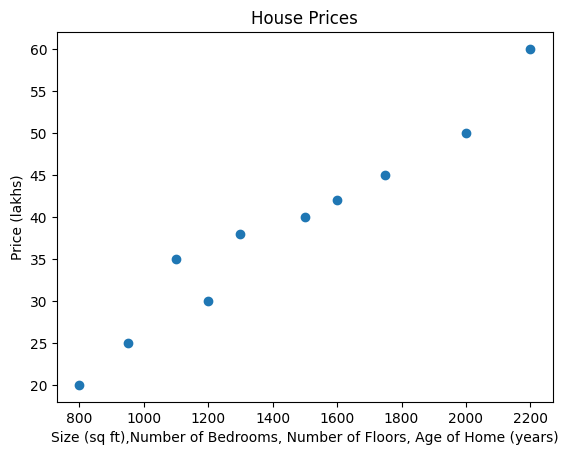

Iteration 0: Cost 627.9721060783721
Iteration 100: Cost 2.3516229142146443
Iteration 200: Cost 2.187015754993355
Iteration 300: Cost 2.1523143404345113
Iteration 400: Cost 2.144745534672514
Iteration 500: Cost 2.14302776776066
Iteration 600: Cost 2.1426072524721707
Iteration 700: Cost 2.142490662235604
Iteration 800: Cost 2.142452705294652
Iteration 900: Cost 2.142438296066904
Final W: [6.03125349 3.52457253 3.34095212 1.45237653]
Final b: 38.49999999999997


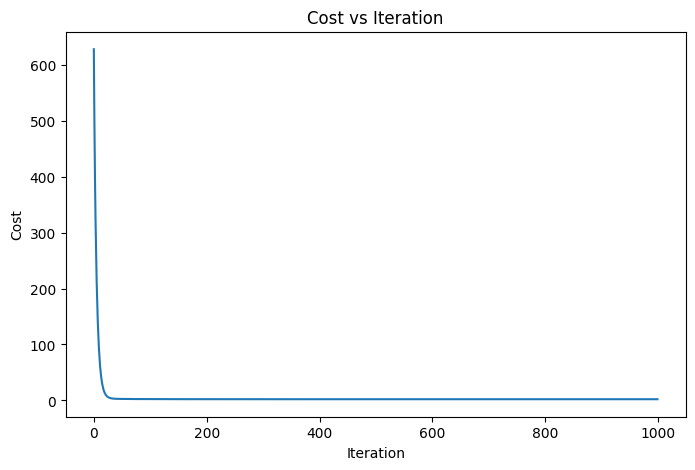

Predicted price for the new house: 44.14285008188757 lakhs


In [5]:
import numpy as np
import matplotlib.pyplot as plt
X_train = np.array([[1200, 2, 3, 5],
    [1500, 3, 5, 2],
    [800,  1, 1, 10],
    [2000, 3, 8, 1],
    [1100, 2, 2, 7],
    [1750, 3, 4, 3],
    [950,  2, 1, 8],
    [2200, 4, 10, 0],
    [1300, 2, 6, 4],
    [1600, 3, 3, 6]],dtype=np.float64)
y_train = np.array([30, 40, 20, 50, 35, 45, 25, 60, 38, 42],dtype=np.float64)
plt.scatter(X_train[:, 0], y_train)
m, n = X_train.shape
print(f"Number of training examples (m): {m}")
print(f"Number of features (n): {n}")
plt.xlabel('Size (sq ft),Number of Bedrooms, Number of Floors, Age of Home (years)')
plt.ylabel('Price (lakhs)')
plt.title('House Prices')
plt.show()

#zcore_Normalization
#Beacuse the features have different scales, we will apply z-score normalization to the features. This will help in improving the performance of our model.
def zscore_normalization(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_normalized = (X - mu) / sigma
    return X_normalized

X_train_normalized = zscore_normalization(X_train)
# prediction function
def predict(X, w, b):
    return np.dot(X, w) + b
# cost function
def compute_cost(X,y, w, b):
    m = X.shape[0]
    predictions = predict(X, w, b)
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost
# compute gradients
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    predictions = predict(X, w, b)
    error = predictions - y
    dw = (1/m)*np.dot(X.T, error)
    db = (1/m)*np.sum(error)
    return dw, db
# gradient descent function
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations):
    w = w_init.copy()
    b = b_init
    cost_history = []
    for i in range(num_iterations):
        dw, db = compute_gradients(X, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost}")
    return w, b, cost_history
# Initialize parameters
w_init = np.zeros(n)
b_init = 0.0
alpha = 0.1
num_iterations = 1000
# Train the model using gradient descent
w_final, b_final, cost_history = gradient_descent(X_train_normalized, y_train, w_init, b_init, alpha, num_iterations)
print(f"Final W: {w_final}")
print(f"Final b: {b_final}")
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()
# Predicting the price of a new house
new_house = np.array([1400, 3, 4, 4], dtype=np.float64)
new_house_normalized = zscore_normalization(new_house)
predicted_price = predict(new_house_normalized, w_final, b_final)
print(f"Predicted price for the new house: {predicted_price[0]} lakhs")